<a href="https://colab.research.google.com/github/sg599/DL_Intel_Image_Classification_Block3_2026/blob/main/Assignment_Intel__Image_classification_Starting_Code_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# From here, add any libraries that you might need for the rest of your code
import random
import numpy as np
from tensorflow.keras import layers, Model
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 2. Load and pre-process the dataset

In [2]:
# IF YOU USE GOOGLE COLAB AND HAVE THE DATA STORED ON YOUR GOOGLE DRIVE:
from google.colab import drive
drive.mount('/content/drive/') # mounts your Google Drive

Mounted at /content/drive/


In [3]:
# SET THE PATHS BASED ON WHERE YOU STORED THE DATASET:

# IF YOU USE GOOGLE COLAB AND HAVE THE DATA STORED ON YOUR GOOGLE DRIVE:
!cp -r "/content/drive/MyDrive/Deep Learning/seg_train/seg_train" /content/ # copies the data from your Google Drive to colab's VM (may take a few mins; set path to your Google directory).
dataset_dir = "/content/seg_train/" # points to the local copy on colab's virtual machine (VM)

# IF YOU USE YOUR OWN COMPUTER:

# LIST THE CLASSES THAT EXIST WITHIN THIS DATASET:
CLASS_LABELS  = ['buildings', 'forest','glacier','mountain','sea','street'] # creates a list of the 6 classes in this dataset (the dataset contains images of 6 types of landscapes)


In [5]:
## IMPORTANT: please remember that you are not allowed to change the
## loading and preprocessing code to improve model performance for this assignment.

# LOAD AND PREPROCESS THE DATA:

# set size of images (in pixels) after resizing
IMG_HEIGHT = 42
IMG_WIDTH = 42

# set batch size
BATCH_SIZE = 128

# set relative sizes of the test and val set
TEST_SIZE = 0.2   # 20% of all x images will be used for testing the model
VAL_SIZE = 0.2    # of the remaining images, 20% will be used for validation and 80% for training

# function for adding noise to the images
def add_noise(img):
    std_coeff = 20 * np.random.random()
    noise = np.random.normal(0, std_coeff, img.shape)
    img += noise
    img = np.clip(img, 0., 255.)
    return img

# build dataframe with file paths and labels
all_files = []
all_labels = []

for class_name in sorted(os.listdir(dataset_dir)):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            all_files.append(fpath)
            all_labels.append(class_name)

df = pd.DataFrame({"filename": all_files, "class": all_labels})

# split the data into train / val / test
trainval_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["class"], random_state=31) # split all data into trainval + test
train_df, val_df   = train_test_split(trainval_df, test_size=VAL_SIZE, stratify=trainval_df["class"], random_state=31)  # split trainval data into train + val

# define generators
train_datagen = ImageDataGenerator(rescale=1./255, preprocessing_function=add_noise) # note: noise is only added to the train samples.
val_test_datagen = ImageDataGenerator(rescale=1./255)

# apply generators
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

val_data = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

test_data = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Data loading completed successfully.")
print(f"Number of training samples: {train_data.samples}")
print(f"Number of validation samples: {val_data.samples}")
print(f"Number of test samples: {test_data.samples}")
print(f"Class names: {train_data.class_indices}")

Found 8981 validated image filenames belonging to 6 classes.
Found 2246 validated image filenames belonging to 6 classes.
Found 2807 validated image filenames belonging to 6 classes.
Data loading completed successfully.
Number of training samples: 8981
Number of validation samples: 2246
Number of test samples: 2807
Class names: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


# 3. Visualise data and plot data distribution

In [6]:
#If you want to visualize the images in their real sizes, you can create a new dataloader and remove the resizing argument as shown below.
#If you want to visualize the images in their resized sizes, you can use the datalaoder as shown in the previous cells.

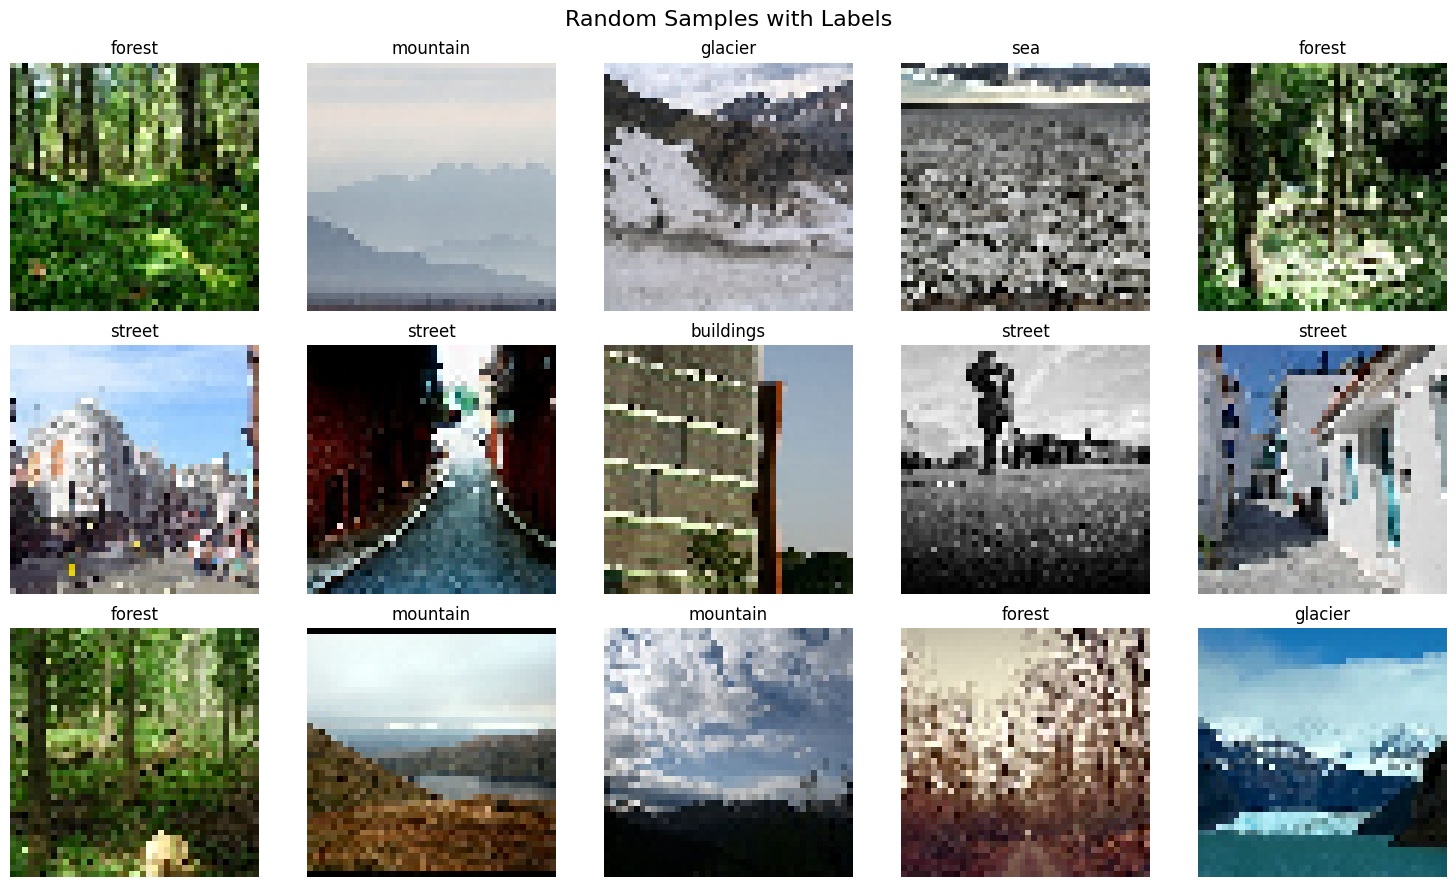

In [7]:
# SOFIA: TASK 1.PART I: 15 SAMPLES WITH LABELS

# df with 15 random samples
rnd_samples = train_df.sample(n = 15, random_state = 123)

plt.figure(figsize=(15, 9))
for i,(_,row) in enumerate(rnd_samples.iterrows()):
  file_path = row["filename"]
  class_label = row["class"]
  img = tf.keras.utils.load_img(file_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
  image_array = tf.keras.utils.img_to_array(img)/255.0

  plt.subplot(3, 5, i+1)
  plt.imshow(image_array)
  plt.title(class_label)
  plt.axis("off")

plt.suptitle("Random Samples with Labels", fontsize=16)
plt.tight_layout()
plt.show()

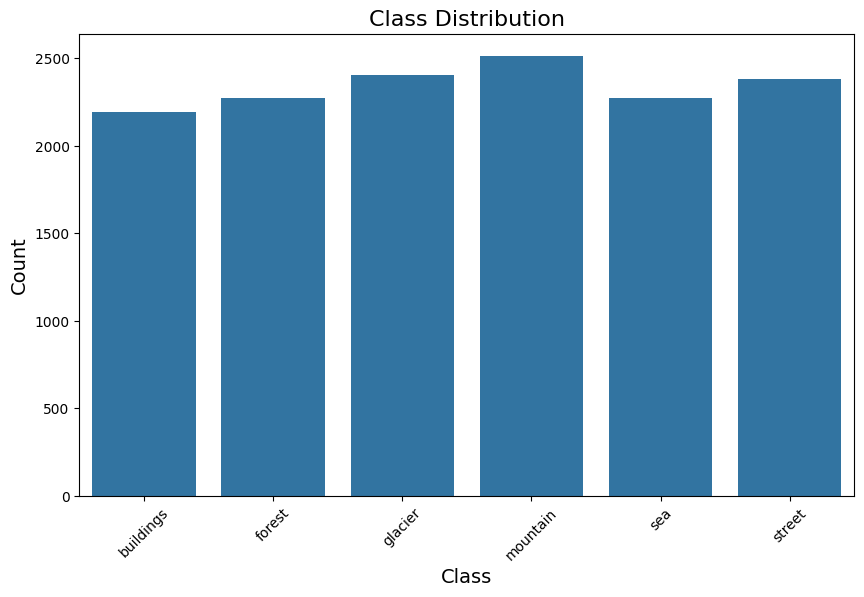

In [8]:
#   SOFIA: TASK 1. PART II. PLOT CLASS DISTRIBUTION
plt.figure(figsize=(10, 6))
sns.countplot(data = df, x = "class", order = CLASS_LABELS)
plt.title("Class Distribution", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

# 4. Model Design and Train and Evaluation functions

In [9]:
#   LAURA: TASK 2. PART I. BASELINE MODEL

# define input
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

## 3 convolution blocks
#1
x = layers.Conv2D(16, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
#2
x = layers.Conv2D(24, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
#3
x = layers.Conv2D(48, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# dense layers
x = layers.Flatten()(x)
x = layers.Dense(1200, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(6, activation='softmax')(x)

# define model
model = Model(inputs=inputs, outputs=x)

# compiling model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# display model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 40, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 48)       │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │       519,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       153,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,446 (2.63 MB)

 Trainable params: 688,446 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#   LAURA: TASK 2. PART II. TRAINING BASELINE MODEL
history = model.fit(train_data, epochs=15, batch_size=64, validation_data= val_data)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.3621 - loss: 1.5322 - val_accuracy: 0.5454 - val_loss: 1.1587
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.5615 - loss: 1.0857 - val_accuracy: 0.6340 - val_loss: 0.9413
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6367 - loss: 0.9348 - val_accuracy: 0.6812 - val_loss: 0.8501
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.6721 - loss: 0.8529 - val_accuracy: 0.6687 - val_loss: 0.8504
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.6937 - loss: 0.8111 - val_accuracy: 0.7093 - val_loss: 0.7950
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.7194 - loss: 0.7447 - val_accuracy: 0.7186 - val_loss: 0.7502
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.7416 - loss: 0.7062 - val_accuracy: 0.7369 - val_loss: 0.7096
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.7484 - loss: 0.6842 - val_accurac

In [11]:
#   LAURA: TASK 2. PART III. BASELINE MODEL PLOTS AND METRICS

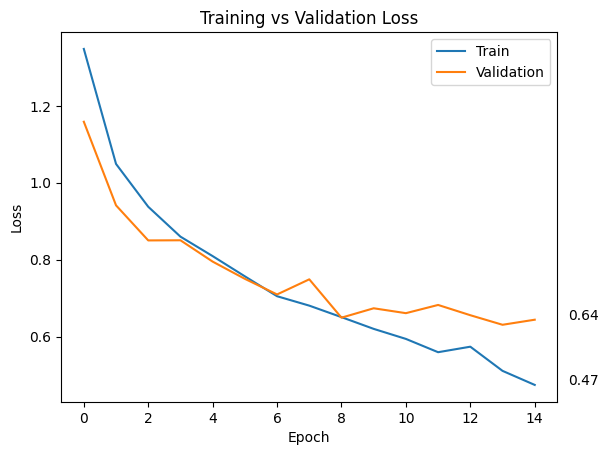

In [12]:
# train vs validation loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

# Part 3 Joyce: I found this on stackoverflow to show the numbers at the end
for var in (history.history['loss'], history.history['val_loss']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')

plt.show()

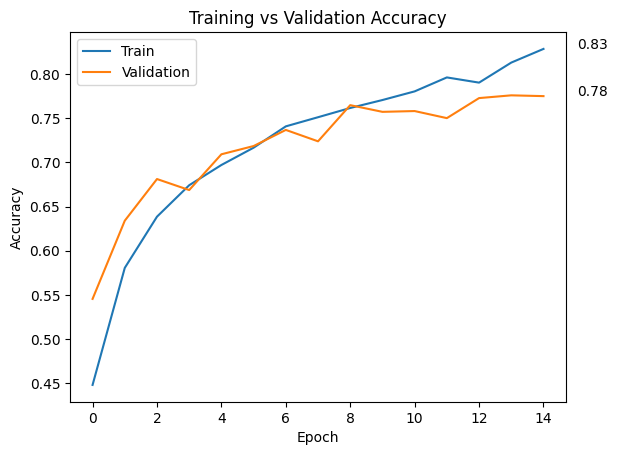

In [13]:
# train vs validation accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Part 3 Joyce: I found this on stackoverflow to show the numbers at the end
for var in (history.history['accuracy'], history.history['val_accuracy']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')

plt.show()

In [20]:
# metrics

accuracy = accuracy_score(y_true_labels, y_pred)
precision = precision_score(y_true_labels, y_pred, average='weighted')
recall = recall_score(y_true_labels, y_pred, average='weighted')
f1 = f1_score(y_true_labels, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nDetailed Classification Report:\n")
print(classification_report(y_true_labels, y_pred))

Accuracy: 0.7709298183113644
Precision: 0.773853964581396
Recall: 0.7709298183113644
F1-score: 0.7705464118413212

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.70      0.71       438
           1       0.89      0.93      0.91       454
           2       0.70      0.77      0.73       481
           3       0.71      0.79      0.75       503
           4       0.82      0.70      0.75       455
           5       0.81      0.73      0.77       476

    accuracy                           0.77      2807
   macro avg       0.78      0.77      0.77      2807
weighted avg       0.77      0.77      0.77      2807



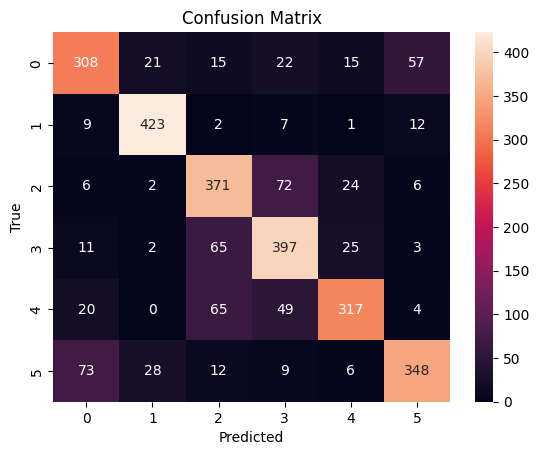

In [19]:
# confusion matrix

# convert probabilities to class predictions
y_pred = np.argmax(y_pred_prob, axis=1)
y_true_labels = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true_labels, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step


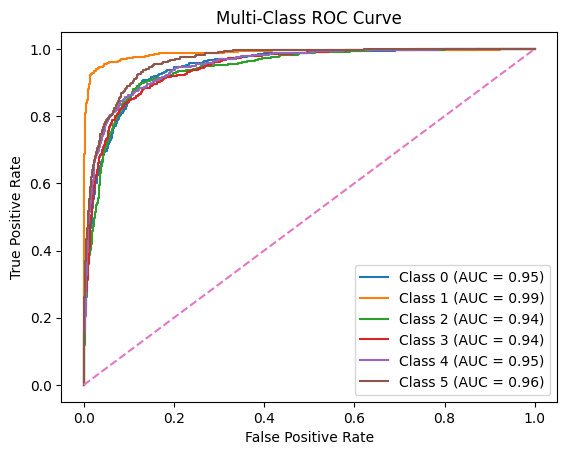

In [17]:
# multi-class ROC + AUC
n_classes = 6

# Predict probabilities
y_pred_prob = model.predict(test_data)

# Get true labels from test_data
# test_data.classes contains the integer labels for each image in the test set
y_true = tf.keras.utils.to_categorical(test_data.classes, num_classes=n_classes)

plt.figure()

for i in range(n_classes):
    # Ensure y_true is properly one-hot encoded for multi-class ROC
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

# 5. Model training

In [27]:
# Karol: TASK 3. PART I. IMPROVED MODEL
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, Model

inputs_imp = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Convolution block 1: Zmiana liczby kanałów (32) i dodanie padding='same'
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs_imp)
x = layers.BatchNormalization()(x) # Nowy hiperparametr: Batch Normalization
x = layers.MaxPooling2D((2, 2))(x)

# Convolution block 2: Zmiana liczby kanałów (64) i dodanie padding='same'
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Convolution block 3: Zmiana liczby kanałów (128) i dodanie padding='same'
x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Dense layers
x = layers.Flatten()(x)
# Zmniejszona liczba neuronów w pojedynczej warstwie Dense (256)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x) # Nowy hiperparametr: Dropout zmniejszony do 0.3
x = layers.Dense(6, activation='softmax')(x)

improved_model = Model(inputs=inputs_imp, outputs=x)

# Nowy hiperparametr: Zmiana Learning Rate na 0.0008
custom_adam = Adam(learning_rate=0.0008)
improved_model.compile(
    optimizer=custom_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 42, 42, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 42, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,142 (3.49 MB)

 Trainable params: 914,694 (3.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
# Karol: TASK 3. PART II. TRAINING IMPROVED MODEL
print("\n--- Training Improved Model ---")
history_imp = improved_model.fit(train_data, epochs=15, batch_size=64, validation_data=val_data)


--- Training Improved Model ---
Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.5063 - loss: 1.7189 - val_accuracy: 0.1790 - val_loss: 3.7592
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.6943 - loss: 0.8060 - val_accuracy: 0.1790 - val_loss: 5.2158
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.7508 - loss: 0.6610 - val_accuracy: 0.3112 - val_loss: 4.0653
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.8002 - loss: 0.5365 - val_accuracy: 0.3865 - val_loss: 3.3459
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8158 - loss: 0.5082 - val_accuracy: 0.4029 - val_loss: 2.5176
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.8609 - loss: 0.3917 - val_accuracy: 0.4831 - val_loss: 1.7622
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8707 - loss: 0.3552 - val_accuracy: 0.6474 - val_loss: 1.1106
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0

# 6. Model evaluation

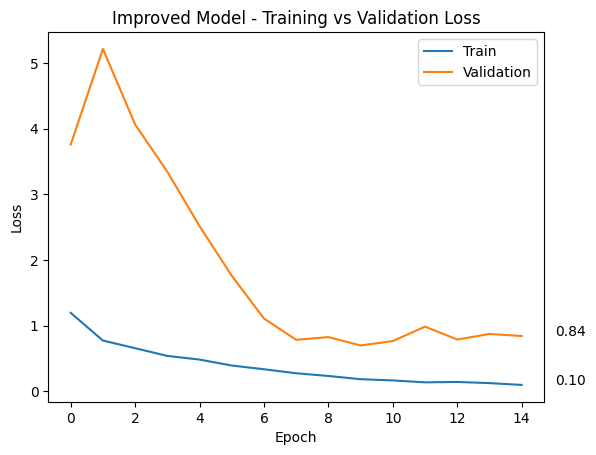

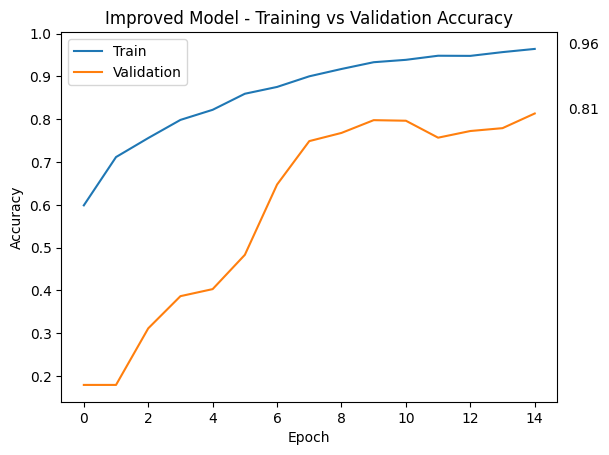

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step
Improved Model - Accuracy: 0.7923049519059494
Improved Model - Precision: 0.8010999995092841
Improved Model - Recall: 0.7923049519059494
Improved Model - F1-score: 0.7933816450870835

Detailed Classification Report (Improved Model):

              precision    recall  f1-score   support

   buildings       0.66      0.86      0.75       438
      forest       0.97      0.90      0.93       454
     glacier       0.78      0.74      0.76       481
    mountain       0.78      0.70      0.74       503
         sea       0.77      0.83      0.80       455
      street       0.84      0.74      0.79       476

    accuracy                           0.79      2807
   macro avg       0.80      0.80      0.79      2807
weighted avg       0.80      0.79      0.79      2807



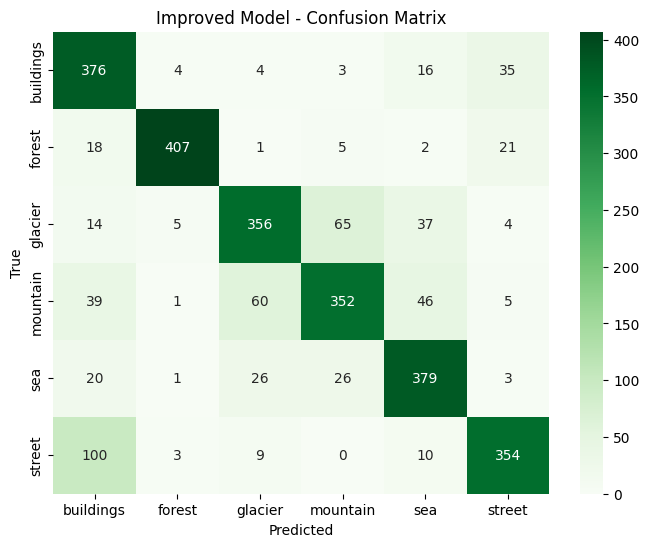

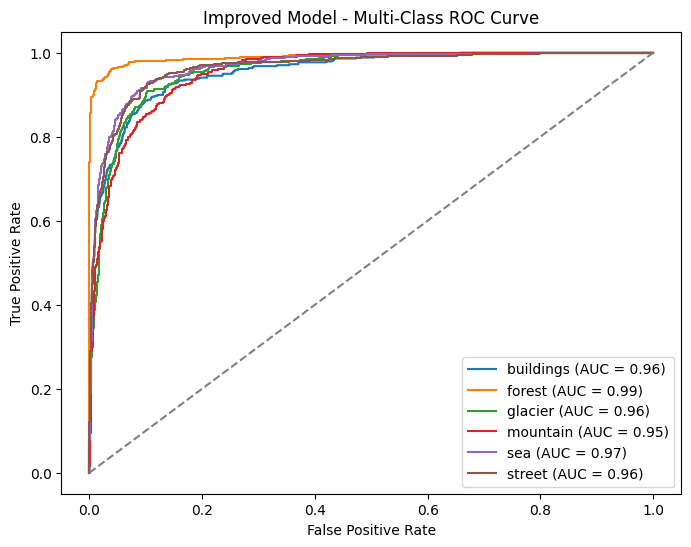

In [29]:
# --- KAROL: TASK 3. PART III. IMPROVED MODEL EVALUATION ---

# 1. W(Loss & Accuracy)
# train vs validation loss
plt.figure()
plt.plot(history_imp.history['loss'])
plt.plot(history_imp.history['val_loss'])
plt.title('Improved Model - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
for var in (history_imp.history['loss'], history_imp.history['val_loss']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')
plt.show()

# train vs validation accuracy
plt.figure()
plt.plot(history_imp.history['accuracy'])
plt.plot(history_imp.history['val_accuracy'])
plt.title('Improved Model - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
for var in (history_imp.history['accuracy'], history_imp.history['val_accuracy']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')
plt.show()

# 2. Evaluation on the test set

test_data.reset()
y_pred_prob_imp = improved_model.predict(test_data)
y_pred_imp = np.argmax(y_pred_prob_imp, axis=1)

# 3. Metryki
accuracy_imp = accuracy_score(y_true_labels, y_pred_imp)
precision_imp = precision_score(y_true_labels, y_pred_imp, average='weighted')
recall_imp = recall_score(y_true_labels, y_pred_imp, average='weighted')
f1_imp = f1_score(y_true_labels, y_pred_imp, average='weighted')

print("Improved Model - Accuracy:", accuracy_imp)
print("Improved Model - Precision:", precision_imp)
print("Improved Model - Recall:", recall_imp)
print("Improved Model - F1-score:", f1_imp)

print("\nDetailed Classification Report (Improved Model):\n")
print(classification_report(y_true_labels, y_pred_imp, target_names=CLASS_LABELS))

# 4. Confusion matrix
cm_imp = confusion_matrix(y_true_labels, y_pred_imp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title('Improved Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5. Multi-class ROC + AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr_imp, tpr_imp, _ = roc_curve(y_true[:, i], y_pred_prob_imp[:, i])
    roc_auc_imp = auc(fpr_imp, tpr_imp)
    plt.plot(fpr_imp, tpr_imp, label=f'{CLASS_LABELS[i]} (AUC = {roc_auc_imp:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Improved Model - Multi-Class ROC Curve')
plt.legend()
plt.show()